Este notebook usa celdas para experimentación y análisis, manteniendo la POO en módulos Python separados (activations.py, layers.py, model.py).

In [1]:
import importlib

import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path



from model import CNN

from activations import ReLU, Softmax

from layers import ConvolutionalLayer, PoolingLayer, DenseLayer

import main as main_module



main_module = importlib.reload(main_module)



load_images_from_directory = main_module.load_images_from_directory

train_test_split = main_module.train_test_split

accuracy_with_threshold = main_module.accuracy_with_threshold

predict_image_file = main_module.predict_image_file

preprocess_image = main_module.preprocess_image


## Construcción del modelo (POO)

La arquitectura se define con objetos de capa y activación.

In [2]:
def build_cnn(num_classes, learning_rate=0.1, confidence_threshold=0.20):
    model = CNN(num_classes=num_classes, confidence_threshold=confidence_threshold)

    model.add(ConvolutionalLayer(input_shape=(3, 64, 64), num_filters=8, filter_size=3, stride=2, padding=1, learning_rate=learning_rate))
    model.add(ReLU())
    model.add(PoolingLayer(pool_size=2, stride=2))

    model.add(ConvolutionalLayer(input_shape=(8, 16, 16), num_filters=16, filter_size=3, stride=2, padding=1, learning_rate=learning_rate))
    model.add(ReLU())
    model.add(PoolingLayer(pool_size=2, stride=2))

    model.add(ConvolutionalLayer(input_shape=(16, 4, 4), num_filters=32, filter_size=3, stride=1, padding=1, learning_rate=learning_rate))
    model.add(ReLU())
    model.add(PoolingLayer(pool_size=2, stride=2))

    model.add(DenseLayer(input_size=32 * 2 * 2, output_size=32, learning_rate=learning_rate))
    model.add(ReLU())
    model.add(DenseLayer(input_size=32, output_size=num_classes, learning_rate=learning_rate))
    model.add(Softmax())

    return model

## Datos reales, entrenamiento y evaluacion

Estructura esperada de carpetas (5 clases):

- dataset/train/Bellpepper, carrot, Cucumber, potato, tomato

- dataset/test/Bellpepper, carrot, Cucumber, potato, tomato (opcional)

Las clases se detectan automaticamente desde las carpetas del dataset.

In [3]:
if "build_cnn" not in globals():
    raise RuntimeError("Ejecuta primero la Celda 4 (definicion de build_cnn).")

import time

image_size = (64, 64)
confidence_threshold = 0.20
epochs_fijos = 35

dataset_root = Path("dataset")
train_dir = dataset_root / "train"
test_dir = dataset_root / "test"

if train_dir.exists():
    class_names_expected = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])
    x_train, y_train, class_names = load_images_from_directory(
        str(train_dir), image_size=image_size, class_names=class_names_expected
    )
    if test_dir.exists():
        x_test, y_test, _ = load_images_from_directory(
            str(test_dir), image_size=image_size, class_names=class_names
        )
    else:
        x_all, y_all, class_names = load_images_from_directory(
            str(dataset_root), image_size=image_size, class_names=class_names_expected
        )
        x_train, y_train, x_test, y_test = train_test_split(x_all, y_all, test_ratio=0.2)
else:
    class_names_expected = sorted([p.name for p in dataset_root.iterdir() if p.is_dir()])
    x_all, y_all, class_names = load_images_from_directory(
        str(dataset_root), image_size=image_size, class_names=class_names_expected
    )
    x_train, y_train, x_test, y_test = train_test_split(x_all, y_all, test_ratio=0.2)

if len(class_names) != 5:
    raise ValueError(f"Debes tener exactamente 5 carpetas de clase. Detectadas: {class_names}")

def random_horizontal_flip_batch(x, flip_prob=0.5):
    x_aug = x.copy()
    mask = np.random.rand(x_aug.shape[0]) < flip_prob
    x_aug[mask] = x_aug[mask, :, :, ::-1]
    return x_aug

x_train_aug = random_horizontal_flip_batch(x_train, flip_prob=0.5)

print(f"Clases detectadas: {class_names}")
print(f"Train: {len(y_train)} | Test: {len(y_test)}")
print(f"Resolucion usada: {image_size[0]}x{image_size[1]}")
print(f"Umbral usado: {confidence_threshold:.2f}")
print(f"Epochs fijos: {epochs_fijos}")
print("Learning rate: 0.1")

model = build_cnn(num_classes=len(class_names), learning_rate=0.1, confidence_threshold=confidence_threshold)

start = time.perf_counter()
model.fit(x_train_aug, y_train, epochs=epochs_fijos, batch_size=16, verbose=True, shuffle=True)
elapsed = time.perf_counter() - start

preds, probs = model.predict(x_test, confidence_threshold=confidence_threshold)
acc_valid, reject_rate = accuracy_with_threshold(preds, y_test)

print(f"Tiempo de entrenamiento: {elapsed:.1f} s")
print(f"Accuracy en muestras aceptadas: {acc_valid:.4f}")
print(f"Tasa de rechazo (Ninguna de las anteriores): {reject_rate:.4f}")

C:\Users\Hermes Aguilera\AppData\Roaming\Python\Python314\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Clases detectadas: ['Bellpepper', 'Carrot', 'Cucumber', 'Potato', 'Tomato']
Train: 1000 | Test: 250
Resolucion usada: 64x64
Umbral usado: 0.20
Epochs fijos: 35
Learning rate: 0.1
Epoch 1/35 - loss: 1.5964 - acc: 0.2990
Epoch 2/35 - loss: 1.5731 - acc: 0.3220
Epoch 3/35 - loss: 1.5433 - acc: 0.3260
Epoch 4/35 - loss: 1.5044 - acc: 0.3300
Epoch 5/35 - loss: 1.4551 - acc: 0.3400
Epoch 6/35 - loss: 1.3956 - acc: 0.3760
Epoch 7/35 - loss: 1.3284 - acc: 0.4130
Epoch 8/35 - loss: 1.2563 - acc: 0.4430
Epoch 9/35 - loss: 1.1798 - acc: 0.5310
Epoch 10/35 - loss: 1.1110 - acc: 0.5270
Epoch 11/35 - loss: 1.0565 - acc: 0.5520
Epoch 12/35 - loss: 1.0228 - acc: 0.5680
Epoch 13/35 - loss: 0.9927 - acc: 0.5750
Epoch 14/35 - loss: 0.9620 - acc: 0.5960
Epoch 15/35 - loss: 0.9375 - acc: 0.6020
Epoch 16/35 - loss: 0.9175 - acc: 0.6180
Epoch 17/35 - loss: 0.8888 - acc: 0.6300
Epoch 18/35 - loss: 0.8693 - acc: 0.6530
Epoch 19/35 - loss: 0.8337 - acc: 0.6610
Epoch 20/35 - loss: 0.8135 - acc: 0.6640
Epoch 21/3

## Búsqueda de umbral de confianza

Este bloque ayuda a calibrar el compromiso entre precisión y rechazo.

In [4]:
for th in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]:
    preds_th, _ = model.predict(x_test, confidence_threshold=th)
    acc_th, rej_th = accuracy_with_threshold(preds_th, y_test)
    print(f'Umbral={th:.2f} | Acc(aceptadas)={acc_th:.4f} | Rechazo={rej_th:.4f}')

Umbral=0.10 | Acc(aceptadas)=0.7720 | Rechazo=0.0000
Umbral=0.15 | Acc(aceptadas)=0.7720 | Rechazo=0.0000
Umbral=0.20 | Acc(aceptadas)=0.7720 | Rechazo=0.0000
Umbral=0.25 | Acc(aceptadas)=0.7720 | Rechazo=0.0000
Umbral=0.30 | Acc(aceptadas)=0.7720 | Rechazo=0.0000
Umbral=0.35 | Acc(aceptadas)=0.7720 | Rechazo=0.0000
Umbral=0.40 | Acc(aceptadas)=0.7810 | Rechazo=0.0320


## Predicciones de ejemplo

Visualización textual de resultados para inspección rápida.

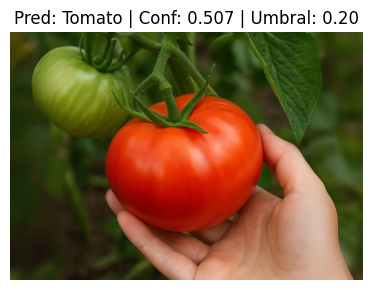

Prediccion: Tomato
Confianza maxima: 0.5071
Umbral usado: 0.20
Etiqueta esperada: Tomato
Coincide: True


In [21]:
from PIL import Image

ruta_imagen = "dataset/test/Tomato/TOMATE3.webp"

etiqueta_esperada = "Tomato"

umbral_inferencia = 0.20
image_size_inferencia = (64, 64)

pred_label, pred_probs = predict_image_file(
    model,
    image_path=ruta_imagen,
    class_names=class_names,
    confidence_threshold=umbral_inferencia,
    image_size=image_size_inferencia,
)

conf = float(np.max(pred_probs))
if isinstance(pred_label, int):
    pred_humana = class_names[pred_label]
else:
    pred_humana = pred_label

img_original = Image.open(ruta_imagen).convert("RGB")

plt.figure(figsize=(5, 3))
plt.imshow(img_original)
plt.axis("off")
plt.title(f"Pred: {pred_humana} | Conf: {conf:.3f} | Umbral: {umbral_inferencia:.2f}")
plt.tight_layout()
plt.show()

print(f"Prediccion: {pred_humana}")
print(f"Confianza maxima: {conf:.4f}")
print(f"Umbral usado: {umbral_inferencia:.2f}")
if etiqueta_esperada:
    print(f"Etiqueta esperada: {etiqueta_esperada}")
    print(f"Coincide: {pred_humana == etiqueta_esperada}")